In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import os


In [3]:
# Load dataset
(ds_train, _), ds_info = tfds.load(
    'fashion_mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

# Normalize and batch
def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5  # Normalize to [-1, 1]
    return image

BATCH_SIZE = 128
BUFFER_SIZE = 60000

train_dataset = ds_train.map(lambda img, lbl: preprocess(img, lbl)).cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.TLQJVK_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.TLQJVK_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


In [4]:
def make_generator_model():
    model = tf.keras.Sequential([
        layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model


In [5]:
def make_discriminator_model():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                      input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model


In [6]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator = make_generator_model()
discriminator = make_discriminator_model()

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(tf.expand_dims(images, -1), training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)
        print(f'Epoch {epoch + 1} completed.')
        generate_and_save_images(generator, epoch + 1, seed)

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()


Epoch 1 completed.


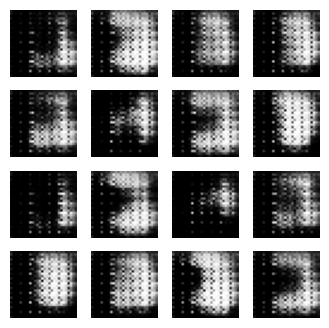

Epoch 2 completed.


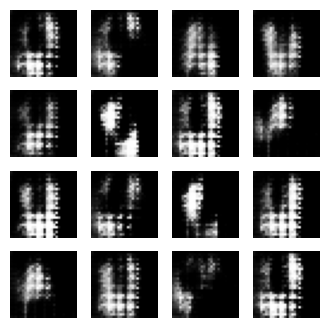

Epoch 3 completed.


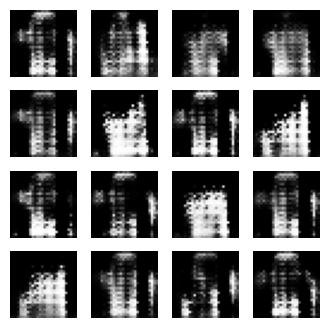

Epoch 4 completed.


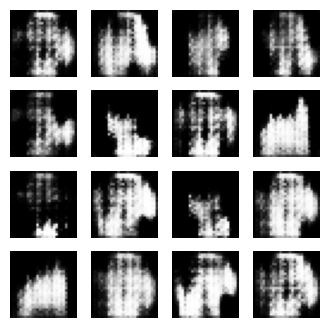

Epoch 5 completed.


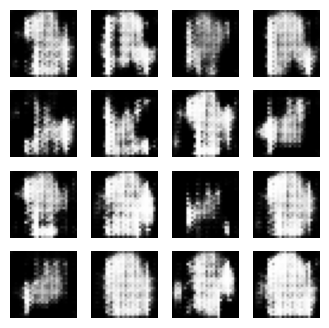

Epoch 6 completed.


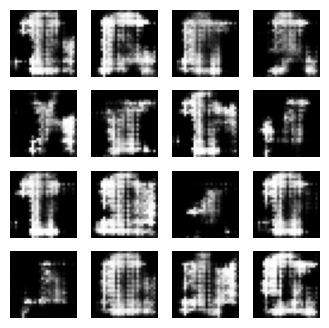

Epoch 7 completed.


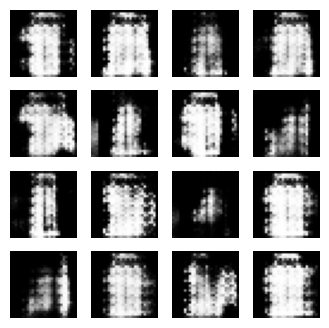

Epoch 8 completed.


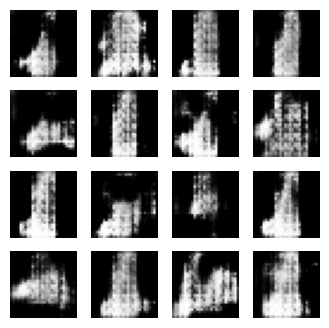

Epoch 9 completed.


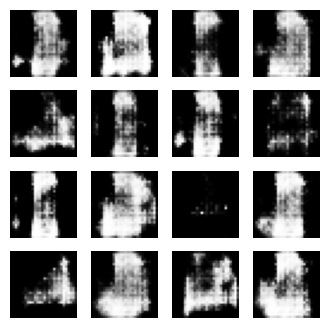

Epoch 10 completed.


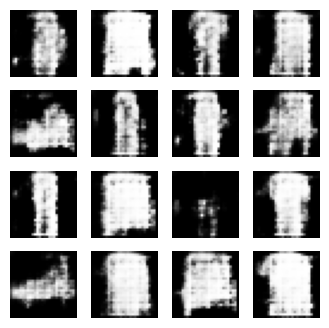

Epoch 11 completed.


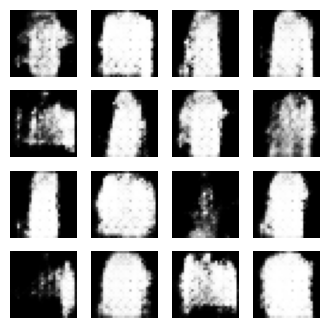

Epoch 12 completed.


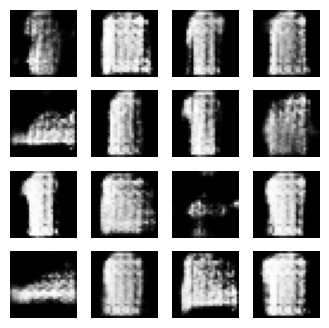

Epoch 13 completed.


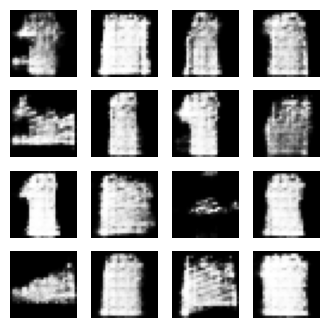

Epoch 14 completed.


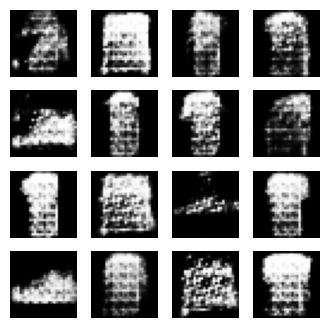

Epoch 15 completed.


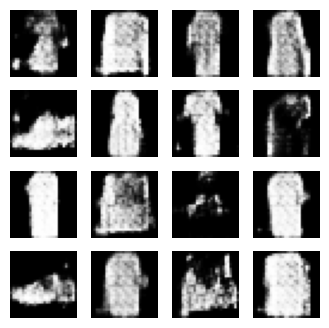

Epoch 16 completed.


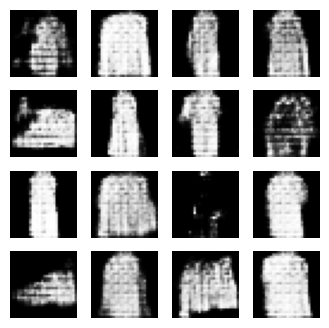

Epoch 17 completed.


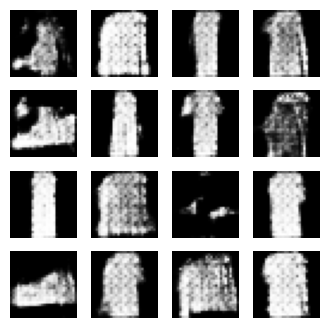

Epoch 18 completed.


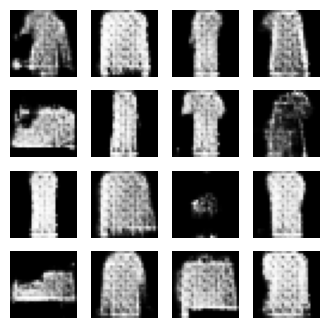

Epoch 19 completed.


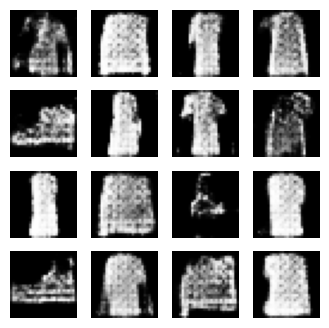

Epoch 20 completed.


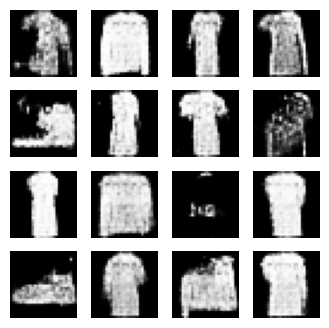

Epoch 21 completed.


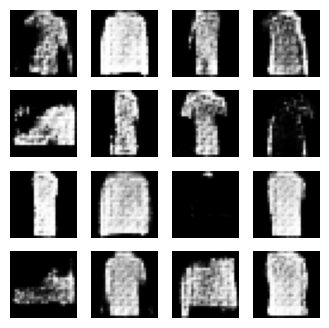

Epoch 22 completed.


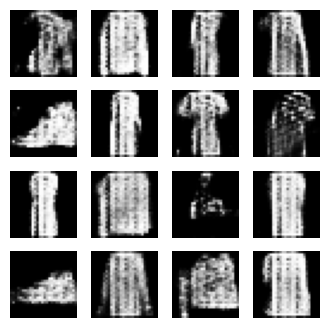

Epoch 23 completed.


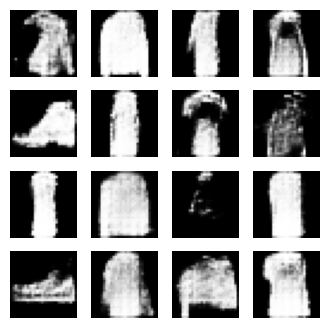

Epoch 24 completed.


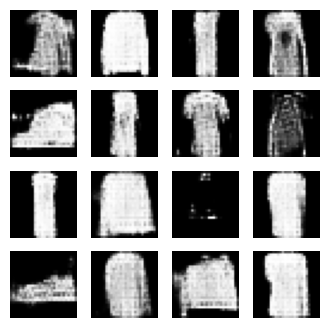

Epoch 25 completed.


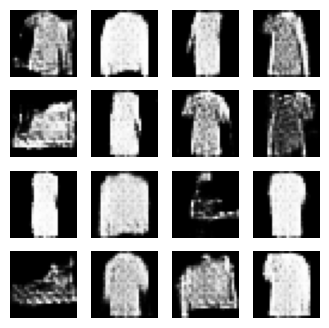

Epoch 26 completed.


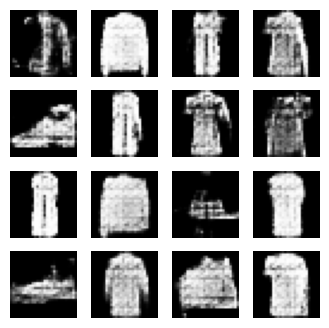

Epoch 27 completed.


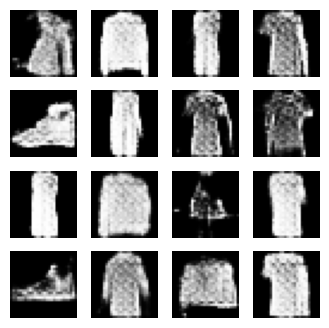

Epoch 28 completed.


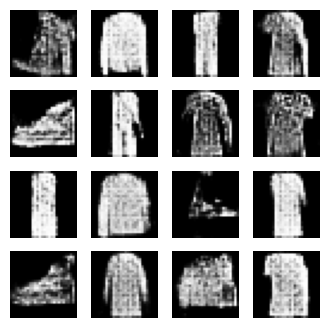

Epoch 29 completed.


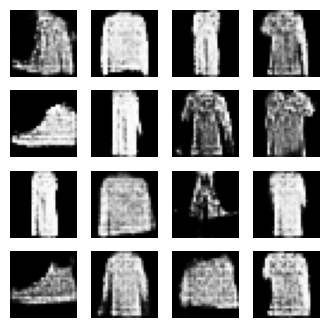

Epoch 30 completed.


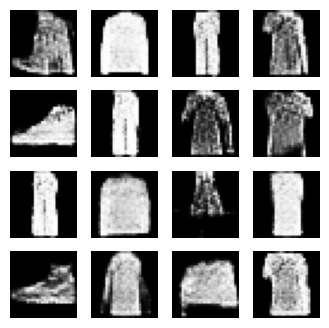

Epoch 31 completed.


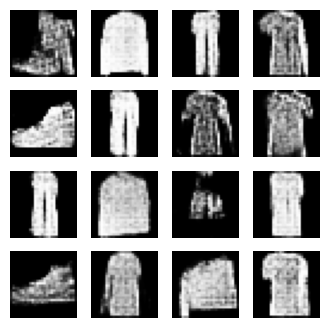

Epoch 32 completed.


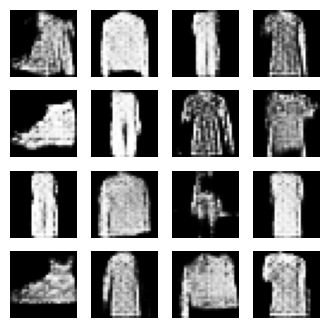

Epoch 33 completed.


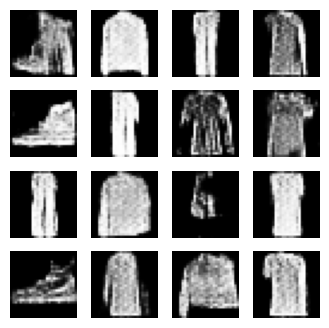

Epoch 34 completed.


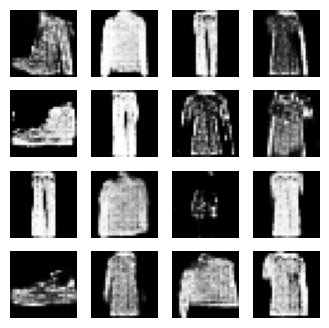

Epoch 35 completed.


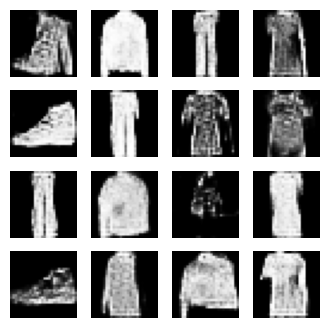

Epoch 36 completed.


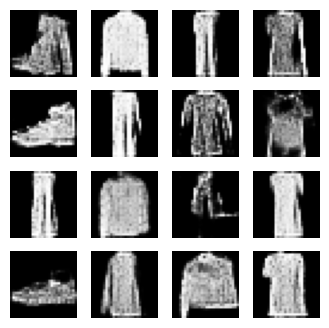

Epoch 37 completed.


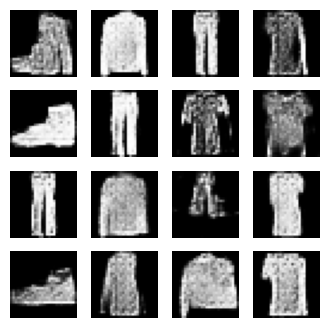

Epoch 38 completed.


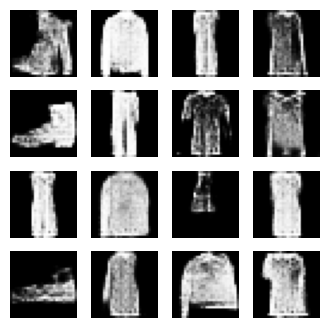

Epoch 39 completed.


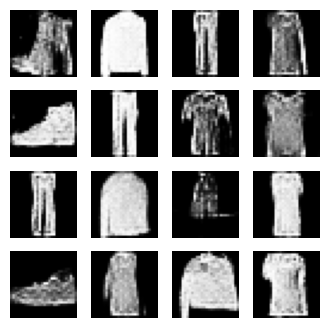

Epoch 40 completed.


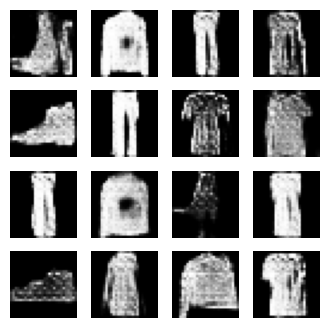

Epoch 41 completed.


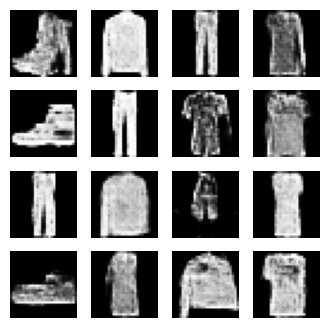

Epoch 42 completed.


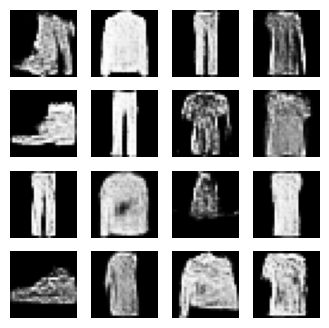

Epoch 43 completed.


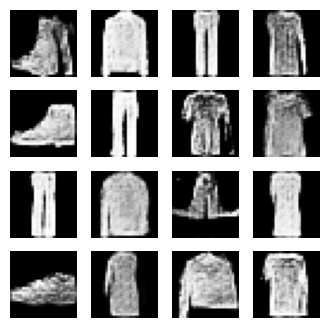

Epoch 44 completed.


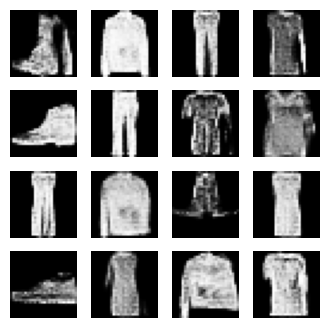

Epoch 45 completed.


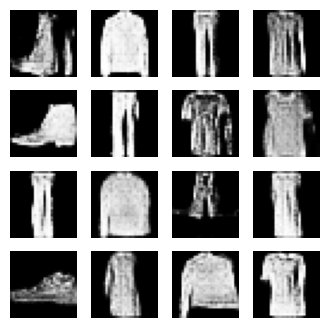

Epoch 46 completed.


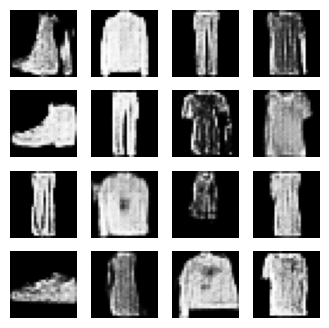

Epoch 47 completed.


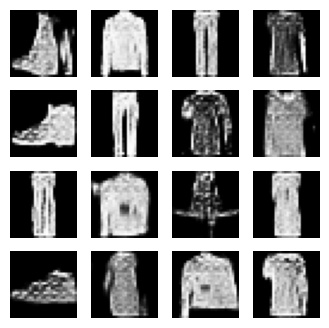

Epoch 48 completed.


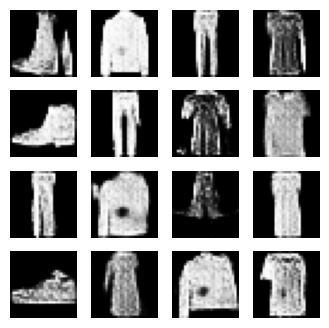

Epoch 49 completed.


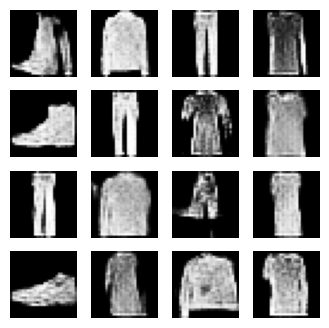

Epoch 50 completed.


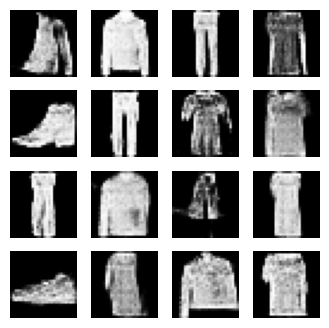

In [8]:
train(train_dataset, EPOCHS)


In [9]:
generator.save('dcgan_fashion_generator.h5')

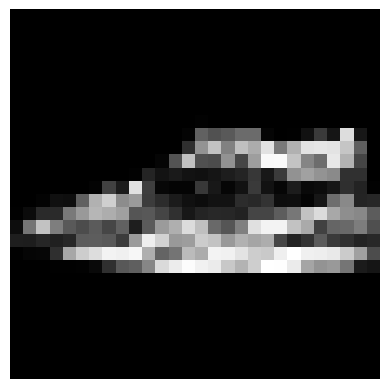

In [10]:
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)
plt.imshow(generated_image[0, :, :, 0] * 127.5 + 127.5, cmap='gray')
plt.axis('off')
plt.show()

In [11]:
gen_loss_list = []
disc_loss_list = []


In [13]:
gen_loss_list = []
disc_loss_list = []

def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        # ----- Loss Evaluation after Epoch -----
        noise = tf.random.normal([BATCH_SIZE, noise_dim])
        generated_images = generator(noise, training=False)

        real_batch = next(iter(dataset))  # Get a fresh real image batch
        real_output = discriminator(tf.expand_dims(real_batch[0], -1), training=False)
        fake_output = discriminator(generated_images, training=False)

        g_loss = generator_loss(fake_output).numpy()
        d_loss = discriminator_loss(real_output, fake_output).numpy()
        gen_loss_list.append(g_loss)
        disc_loss_list.append(d_loss)

        # Save generated images
        save_generated_images(generator, epoch + 1, seed)
        print(f"Epoch {epoch+1} completed in {time.time() - start:.2f}s | Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}")

    print("Training finished.")


In [18]:
gen_loss_list = []
disc_loss_list = []


In [19]:
for epoch in range(epochs):
    for image_batch in dataset:
        train_step(image_batch)

    # Get one batch of real images
    real_batch = next(iter(dataset))
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    generated_images = generator(noise, training=False)

    real_output = discriminator(real_batch, training=False)
    fake_output = discriminator(generated_images, training=False)

    g_loss = generator_loss(fake_output).numpy()
    d_loss = discriminator_loss(real_output, fake_output).numpy()

    gen_loss_list.append(g_loss)
    disc_loss_list.append(d_loss)

    print(f"Epoch {epoch + 1}, Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}")


NameError: name 'epochs' is not defined

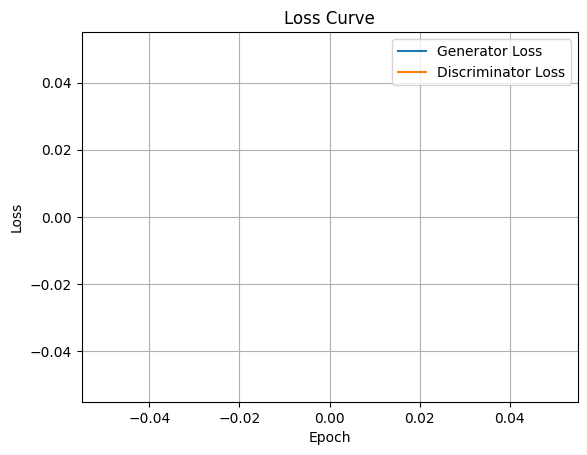

In [17]:
import matplotlib.pyplot as plt

plt.plot(gen_loss_list, label='Generator Loss')
plt.plot(disc_loss_list, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import imageio
import glob

def create_training_gif():
    image_paths = sorted(glob.glob('image_at_epoch_*.png'))
    images = [imageio.imread(path) for path in image_paths]
    imageio.mimsave('dcgan_fashion_training.gif', images, fps=4)

create_training_gif()


In [ ]:
# Example: Stop if generator loss doesn't improve
if epoch > 5 and abs(gen_loss_list[-1] - gen_loss_list[-2]) < 0.001:
    print("Early stopping triggered.")
    break

In [ ]:
generator.save('generator_model.h5')
discriminator.save('discriminator_model.h5')

In [ ]:
generator = tf.keras.models.load_model('generator_model.h5', compile=False)


In [ ]:
import gradio as gr

def generate_image_from_noise(z):
    z = tf.convert_to_tensor(z.reshape(1, 100), dtype=tf.float32)
    generated = generator(z, training=False)[0, :, :, 0]
    return (generated.numpy() * 127.5 + 127.5).astype(np.uint8)

gr.Interface(
    fn=generate_image_from_noise,
    inputs=gr.inputs.Slider(minimum=-2, maximum=2, step=0.01, label="Noise Vector (z)"),
    outputs="image"
).launch()